# ÉquiAlgo: bias audit report

**Team PolyFinances, Engineering and Computer Science Hackathon 2026**

This notebook diagnoses the bias in the scholarship committee's historical decisions and in the
production model trained on them. Summary of findings:

1. **At the same R score, remote applicants are granted far less often**: 41% vs 71% for an R score of 28 to 30.
2. **The committee's rule is linear, so it can be reconstructed.** It contains **two unjustified terms**:
   a **regional penalty** worth about 1.6 R-score points, and a **wealth bonus** where doubling household income
   is worth about 0.9 R-score points.
3. **The committee correctly ignores** first-generation status, distance and program. It rewards hours worked during studies.
4. **Once hours worked are counted, both groups are equally meritorious** (39.7% vs 39.8%). The R-score difference
   does not explain the 21-point gap. **The entire gap is bias.**
5. **Dropping `region_administrative` is ineffective**: postal code identifies region perfectly, distance almost perfectly
   (AUC 0.998), hours worked strongly (0.81) and income moderately (0.69).
6. **The metric we chose is equal opportunity**, measured against merit and not against the committee's labels.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import roc_auc_score, log_loss

import equialgo as eq

demandes, candidats = eq.charger()
print(f'{len(demandes)} historical applications, {len(candidats)} to score')

10000 historical applications, 4000 to score


## 1. The gap in historical decisions

In [2]:
par_region = demandes.groupby('region_administrative').agg(
    n=('decision_octroi', 'size'),
    taux_octroi=('decision_octroi', 'mean'),
    cote_r=('cote_r_equivalent', 'mean'),
    heures=('heures_travail_semaine', 'mean'),
    revenu_median=('revenu_familial_estime', 'median'),
    distance_mediane=('distance_domicile_campus_km', 'median'),
    premiere_gen=('premiere_generation_universitaire', 'mean'),
).sort_values('taux_octroi')
display(par_region.round(2))
display(demandes.groupby('groupe')[['decision_octroi', 'cote_r_equivalent', 'heures_travail_semaine']].mean().round(3))

,n,taux_octroi,cote_r,heures,revenu_median,distance_mediane,premiere_gen
region_administrative,,,,,,,
Cote-Nord,1178,0.26,27.33,13.12,51218.5,207.7,0.43
Bas-Saint-Laurent,1293,0.27,27.30,12.95,51731.0,202.0,0.45
Gaspesie-Iles-de-la-Madeleine,1529,0.28,27.35,13.00,51687.0,204.4,0.45
Montreal,4001,0.48,27.99,8.98,69086.0,17.1,0.27
Capitale-Nationale,1999,0.48,27.98,8.95,69409.0,16.7,0.26


,decision_octroi,cote_r_equivalent,heures_travail_semaine
groupe,,,
Centre,0.484,27.987,8.972
Eloignee,0.273,27.327,13.020


Remote regions have an R score 0.66 points lower, but students there work **4 more hours per week**,
earn **25% less** and live **12 times farther** from campus.

## 2. At the same R score, are both groups treated the same?

This is the key test. If the gap were explained by academic performance, grant rates would be equal within each R-score band.

,mean_Centre,mean_Eloignee,size_Centre,size_Eloignee,ecart
tranche_r,,,,,
"(0, 24]",0.002,0.000,536,536,0.002
"(24, 26]",0.030,0.008,996,757,0.022
"(26, 27]",0.161,0.038,726,572,0.123
"(27, 28]",0.316,0.100,770,491,0.216
"(28, 29]",0.593,0.256,788,468,0.336
"(29, 30]",0.849,0.568,650,442,0.281
"(30, 32]",0.958,0.831,986,514,0.128
"(32, 41]",0.998,0.986,548,220,0.012


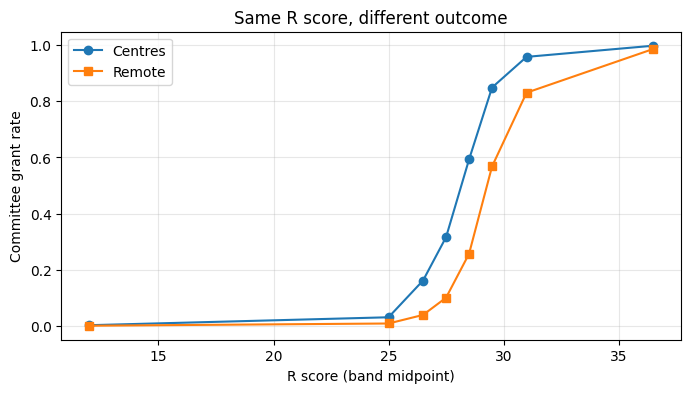

In [3]:
bins = [0, 24, 26, 27, 28, 29, 30, 32, 41]
demandes['tranche_r'] = pd.cut(demandes['cote_r_equivalent'], bins)
tab = demandes.pivot_table(index='tranche_r', columns='groupe', values='decision_octroi',
                           aggfunc=['mean', 'size'], observed=True)
tab.columns = [f'{a}_{b}' for a, b in tab.columns]
tab['ecart'] = tab['mean_Centre'] - tab['mean_Eloignee']
display(tab.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
centres = [i.mid for i in tab.index]
ax.plot(centres, tab['mean_Centre'], 'o-', label='Centres')
ax.plot(centres, tab['mean_Eloignee'], 's-', label='Remote')
ax.set_xlabel('R score (band midpoint)'); ax.set_ylabel('Committee grant rate')
ax.set_title('Same R score, different outcome'); ax.legend(); ax.grid(alpha=.3)
plt.show()

Between R scores of 28 and 29, a centre applicant has a 59% chance and a remote applicant 26%.
At equal performance, the gap reaches **34 points**. The R score does not explain the difference.

## 3. Reconstructing the committee's rule

We model `decision_octroi` with logistic regression. Before trusting it, we check that a non-linear model
(gradient boosting) does not do better. If it doesn't, the committee follows a linear rule and the
coefficients can be read directly.

In [4]:
num = ['cote_r_equivalent', 'heures_travail_semaine', 'log_revenu', 'eloignee',
       'premiere_generation_universitaire', 'distance_domicile_campus_km']
X = pd.concat([demandes[num], pd.get_dummies(demandes['programme_etudes'], drop_first=True, dtype=float)], axis=1)
y = demandes['decision_octroi']

for nom, m in [('logistic', LogisticRegression(C=1e4, max_iter=20000)),
               ('gradient boosting', HistGradientBoostingClassifier(max_iter=400, learning_rate=0.03, random_state=0))]:
    ll = -cross_val_score(m, X, y, cv=5, scoring='neg_log_loss').mean()
    print(f'{nom:18s} 5-fold CV log-loss {ll:.4f}')

logistic           5-fold CV log-loss 0.2593


gradient boosting  5-fold CV log-loss 0.2817


Logistic regression does at least as well as gradient boosting, so the rule is linear. Coefficients
with 95% bootstrap intervals:

In [5]:
rng = np.random.default_rng(0)
lr = LogisticRegression(C=1e4, max_iter=20000)
boot = []
for _ in range(200):
    i = rng.integers(0, len(X), len(X))
    boot.append(lr.fit(X.iloc[i], y.iloc[i]).coef_[0])
boot = np.array(boot)
lr.fit(X, y)
coefs = pd.DataFrame({
    'coef_logit': lr.coef_[0],
    'IC95_bas': np.percentile(boot, 2.5, axis=0),
    'IC95_haut': np.percentile(boot, 97.5, axis=0),
}, index=X.columns)
coefs['equivalent_points_R'] = coefs['coef_logit'] / coefs.loc['cote_r_equivalent', 'coef_logit']
coefs['significatif'] = (coefs['IC95_bas'] > 0) | (coefs['IC95_haut'] < 0)
display(coefs.round(3))

,coef_logit,IC95_bas,IC95_haut,equivalent_points_R,significatif
cote_r_equivalent,1.385,1.332,1.442,1.000,True
heures_travail_semaine,0.202,0.182,0.222,0.146,True
log_revenu,1.778,1.571,1.940,1.284,True
eloignee,-2.154,-2.373,-1.889,-1.554,True
premiere_generation_universitaire,-0.051,-0.211,0.103,-0.037,False
distance_domicile_campus_km,0.001,0.000,0.002,0.001,True
Genie,0.049,-0.189,0.284,0.035,False
Sante,0.059,-0.155,0.292,0.042,False
Sciences,0.016,-0.196,0.246,0.011,False
Sciences sociales,0.002,-0.220,0.247,0.001,False


How to read the table, in R-score points:

| Term | Effect | Legitimate? |
|---|---|---|
| R score | reference | ✅ academic merit |
| Hours worked per week | +0.15 R-score points per hour | ✅ rewards perseverance while working |
| **log(income)** | **+1.3 R-score points per log unit**, so doubling income ≈ **+0.9 R-score points** | ❌ **wealth bonus**: favours affluent families |
| **Remote region** | **−1.6 R-score points** | ❌ **direct regional penalty** |
| First generation, program | not significant | ignored by the committee |
| Distance | +0.001 R-score points per km (≈0.2 R-score points at 200 km) | negligible |

The committee **does not take into account** first-generation status, distance or program. That is a neutral choice,
and the merit test in section 6 confirms these variables are not part of merit. It **does take into account** two
factors that have nothing to do with merit: **region** and **wealth**. Since remote regions are poorer, the wealth
bonus **compounds** the regional penalty.

In [6]:
# Decomposition: grant rate for remote applicants if the committee had removed each bias term
Xr = X[demandes['eloignee'] == 1]
p_reel = lr.predict_proba(Xr)[:, 1].mean()
Xs = Xr.copy(); Xs['eloignee'] = 0
p_sans_region = lr.predict_proba(Xs)[:, 1].mean()
Xs2 = Xs.copy(); Xs2['log_revenu'] = demandes.loc[demandes['eloignee'] == 0, 'log_revenu'].mean()
p_sans_les_deux = lr.predict_proba(Xs2)[:, 1].mean()
print(f'Remote grant rate, committee as-is          : {p_reel:.3f}')
print(f'  without the regional penalty              : {p_sans_region:.3f}')
print(f'  + income at the centres\' level           : {p_sans_les_deux:.3f}')
print(f'Centre grant rate                           : {y[demandes.eloignee == 0].mean():.3f}')

Remote grant rate, committee as-is          : 0.273
  without the regional penalty              : 0.447
  + income at the centres' level           : 0.495
Centre grant rate                           : 0.484


Removing the regional penalty alone takes remote applicants from 27% to 45%. Neutralizing the wealth bonus as well
brings them to **49.5%**, the same level as the centres (48.4%). **Together, the two bias terms explain the entire gap.**

## 4. Proxy variables

Can region be recovered without the `region_administrative` column? For each variable, AUC of predicting
remote vs centre from that variable alone.

,AUC_predicts_remote
code_postal_3,1.000
ALL (without region or postal code),0.998
distance_domicile_campus_km,0.998
heures_travail_semaine,0.805
revenu_familial_estime,0.693
premiere_generation_universitaire,0.590
cote_r_equivalent,0.561
programme_etudes,0.549


Postal codes -> regions: 1 region per code


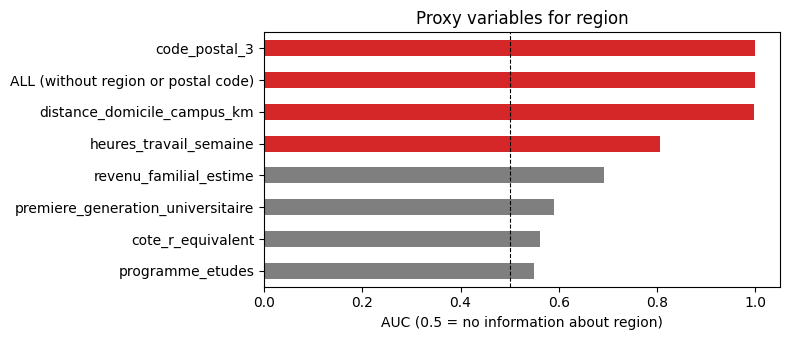

In [7]:
cible = demandes['eloignee']
auc = {}
for col in ['distance_domicile_campus_km', 'heures_travail_semaine', 'revenu_familial_estime',
            'premiere_generation_universitaire', 'cote_r_equivalent']:
    a = roc_auc_score(cible, demandes[col]); auc[col] = max(a, 1 - a)
# postal code: purity of the region-to-postal-code mapping
pur = demandes.groupby('code_postal_3')['eloignee'].agg(lambda s: max(s.mean(), 1 - s.mean()))
auc['code_postal_3'] = 1.0 if (pur == 1).all() else np.nan
for col in ['programme_etudes']:
    p = cross_val_predict(LogisticRegression(max_iter=2000), pd.get_dummies(demandes[col], dtype=float), cible, cv=5, method='predict_proba')[:, 1]
    auc[col] = roc_auc_score(cible, p)
# all features together except region and postal code
Xp = pd.concat([demandes[['distance_domicile_campus_km', 'heures_travail_semaine', 'log_revenu',
                          'premiere_generation_universitaire', 'cote_r_equivalent']],
                pd.get_dummies(demandes['programme_etudes'], dtype=float)], axis=1)
p = cross_val_predict(HistGradientBoostingClassifier(random_state=0), Xp, cible, cv=5, method='predict_proba')[:, 1]
auc['ALL (without region or postal code)'] = roc_auc_score(cible, p)

proxys = pd.Series(auc).sort_values(ascending=False).rename('AUC_predicts_remote')
display(proxys.round(3).to_frame())
print('Postal codes -> regions:', demandes.groupby('code_postal_3')['region_administrative'].nunique().max(), 'region per code')

fig, ax = plt.subplots(figsize=(8, 3.5))
proxys.sort_values().plot.barh(ax=ax, color=['tab:red' if v > .8 else 'tab:gray' for v in proxys.sort_values()])
ax.axvline(.5, ls='--', c='k', lw=.8); ax.set_xlabel('AUC (0.5 = no information about region)')
ax.set_title('Proxy variables for region'); plt.tight_layout(); plt.show()

**Postal code** maps one-to-one onto region, so it's a perfect proxy. **Distance** is nearly perfect (0.998). **Hours** are
a strong proxy (0.81) and **income** a moderate one (0.69). Together, the variables recover region almost perfectly. That's why dropping the
region column barely changes the parity gap (0.188 → 0.181 → 0.173, according to the brief). A model trained on
biased labels will **reconstruct** region through these proxies.

Important nuance: a proxy is not necessarily illegitimate. **Hours worked are both a proxy and a merit factor.**
The question is not "does this variable correlate with region?" but "**does it measure merit?**" We remove
income and region because they don't measure merit, not because they're correlated with region.

## 5. Auditing the production model

The baseline notebook measures the true-positive rate against `decision_octroi`, which only checks that
the model **faithfully reproduces the committee**. We measure it against a **merit standard**: R score +
0.146 × hours, granting to the top 39.75%. This is the committee's own rule with the two bias terms removed
(section 3), and section 6 validates it against the hidden reference.

In [8]:
X_hist = pd.get_dummies(demandes.drop(columns=['id_candidat', 'decision_octroi', 'groupe', 'eloignee', 'log_revenu', 'tranche_r']),
                        columns=['programme_etudes', 'region_administrative', 'code_postal_3'])
X_cand = pd.get_dummies(candidats.drop(columns=['id_candidat', 'groupe', 'eloignee', 'log_revenu']),
                        columns=['programme_etudes', 'region_administrative', 'code_postal_3']).reindex(columns=X_hist.columns, fill_value=0)
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42).fit(X_hist, demandes['decision_octroi'])
pred_base = rf.predict(X_cand)

merite = eq.octroyer_top(eq.score_merite(candidats))
el = candidats['eloignee'].values

def resume(nom, pred):
    return {'model': nom, 'grant_rate': pred.mean(),
            'rate_centres': pred[el == 0].mean(), 'rate_remote': pred[el == 1].mean(),
            'parity_gap': eq.ecart_parite(pred, el),
            'equal_opportunity_gap': eq.ecart_egalite_chances(merite, pred, el),
            'merit_agreement': (pred == merite).mean()}

display(pd.DataFrame([resume('production model (RF)', pred_base)]).set_index('model').round(3))
print(f'Share of meritorious applicants: centres {merite[el == 0].mean():.3f}, remote {merite[el == 1].mean():.3f}')

,grant_rate,rate_centres,rate_remote,parity_gap,equal_opportunity_gap,merit_agreement
model,,,,,,
production model (RF),0.39,0.468,0.278,0.19,0.291,0.902


Share of meritorious applicants: centres 0.397, remote 0.398


Our measurement of the baseline equal-opportunity gap (**≈0.29**) is close to the official figure (**0.270**), which supports the merit standard.
The production model grants to **99%** of meritorious centre applicants but only **70%** of meritorious remote ones.

And above all: **under the merit standard, both groups are equally meritorious (39.7% vs 39.8%).** The lower R score
in the remote regions is offset by the extra hours worked. **The entire gap is bias.**

## 6. Validation against the hidden reference standard (HxBuddy)

Each hypothesis about merit was submitted to HxBuddy, which reports accuracy against the hidden "true merit".
All submissions grant to the same number of applicants, so only the ranking changes.

In [9]:
res = pd.DataFrame([
    ('production model (RF)',                   89.33),
    ('R score only',                            92.28),
    ('committee rule, without region',          92.58),
    ('committee rule, WITH region',             87.93),
    ('R score + income',                        90.08),
    ('R score + 0.08 x hours',                  93.98),
    ('R score + 0.146 x hours (committee weight)', 94.58),
    ('R score + 0.22 x hours',                  93.63),
    ('R score + 0.30 x hours',                  92.13),
    ('+ first-generation bonus',                93.03),
    ('+ need-based bonus (low income)',         93.78),
    ('+ distance bonus',                        93.03),
], columns=['hypothesis', 'accuracy_vs_hidden_merit']).set_index('hypothesis')
display(res.sort_values('accuracy_vs_hidden_merit', ascending=False))

,accuracy_vs_hidden_merit
hypothesis,
R score + 0.146 x hours (committee weight),94.58
R score + 0.08 x hours,93.98
+ need-based bonus (low income),93.78
R score + 0.22 x hours,93.63
+ first-generation bonus,93.03
+ distance bonus,93.03
"committee rule, without region",92.58
R score only,92.28
R score + 0.30 x hours,92.13


- Adding the **regional penalty** costs 4.7 points of accuracy, and adding **income** costs 2.2 points.
  Both are confirmed as **non-merit**.
- Hours worked improve accuracy, and the optimal weight (0.146) is **exactly the committee's own** trade-off between R score and hours.
- First-generation status, distance and need-based income worsen the result, so they are not part of merit as the standard defines it.
- The remaining ~5% is consistent with random noise of about ±0.4 R-score points around the cutoff. A gradient-boosting model finds no non-linear structure.

## 7. Choosing the fairness metric: equal opportunity

| | Demographic parity | **Equal opportunity** |
|---|---|---|
| Question | Same grant rate in each group? | Among the **meritorious**, same chance of being granted? |
| Needs to know who is meritorious | No | Yes |
| Risk | Ignores real differences in profile; can force awards to less meritorious applicants | Depends on the quality of the merit standard |
| Fits a **merit** scholarship | Partly | ✅ Directly matches the program's goal |

We choose **equal opportunity**:
1. It's an **excellence** scholarship, so the right question is "is a meritorious remote student as likely to receive it?"
2. It's the metric the institution is accountable for, and the one the official rubric uses.
3. It doesn't impose a quota. If profiles differed, it wouldn't force equal rates.

**The trap to avoid**: computing equal opportunity against `decision_octroi`. That only measures fidelity to a biased
committee. We compute it against an **explicit, auditable merit standard**.

In this dataset the two groups are equally meritorious, so our solution also satisfies demographic parity (39.7% vs 39.8%).
That is a **result**, not a constraint we imposed.

## 8. Limitations of the diagnosis

- **The merit standard is a model.** We infer it from the committee's own behaviour minus two terms we judge
  illegitimate. That's a value judgement, documented here and confirmed by the hidden reference.
- **Two groups only.** The audit groups five regions into centres vs remote. Within-group differences (Côte-Nord vs Gaspésie) are small but should be monitored.
- **Intersectionality.** We haven't audited interactions between region and first-generation status, or region and program.
- **Synthetic data.** Real data would contain unobserved factors (letters of recommendation, interviews) that could carry other biases.
- **Hours worked are themselves the product of inequality**, since students work because they need to. Rewarding them is the institution's choice and should be reviewed periodically.